In [ ]:
from pathlib import Path
import os, sys, subprocess, json, urllib.request, gzip, shutil, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
ROOT=Path('/content/transformer_cosine')
OUT=ROOT/'results'
for p in [ROOT,OUT,ROOT/'sources',ROOT/'weights',ROOT/'sequences']: p.mkdir(parents=True,exist_ok=True)
N_SEQUENCES=8
SEED=42
LENGTHS={'enformer':196608,'borzoi':524288,'alphagenome':1048576}
SCORE_BP=114688
CONFIG=dict(lengths=LENGTHS,score_bp=SCORE_BP,n_sequences=N_SEQUENCES,seed=SEED)
(ROOT/'config.json').write_text(json.dumps(CONFIG))
(OUT/'config.json').write_text(json.dumps(CONFIG))
subprocess.run(['nvidia-smi'],check=True)
def download(url,target):
    target=Path(target)
    if target.exists() and target.stat().st_size: return target
    tmp=target.with_suffix(target.suffix+'.part')
    with urllib.request.urlopen(url) as r, open(tmp,'wb') as f:
        with tqdm(total=int(r.headers.get('Content-Length',0)) or None,unit='B',unit_scale=True,desc=target.name) as bar:
            while chunk:=r.read(8388608): f.write(chunk);bar.update(len(chunk))
    tmp.replace(target)
    return target


In [ ]:
subprocess.run([sys.executable,'-m','pip','install','-q','uv'],check=True)
UV=shutil.which('uv')
PINS={'deepmind-research':'f5de0ede8430809180254ee957abf36ed62579ef','borzoi':'6503ea5d9f5e27a6ec6f6488c1d0a00a069cd5b0','baskerville':'2e72644f77416e24a4d88cf952f67df8ec056435','alphagenome_research':'eecf3d60234dda0428f5f083d22e518b72487ce0'}
for repo,owner in [('borzoi','calico'),('baskerville','calico'),('alphagenome_research','google-deepmind')]:
    target=ROOT/'sources'/repo
    if not (target/'.git').exists(): subprocess.run(['git','clone','--filter=blob:none',f'https://github.com/{owner}/{repo}.git',str(target)],check=True)
    subprocess.run(['git','-C',str(target),'checkout','--detach',PINS[repo]],check=True)
enf=ROOT/'sources/enformer';enf.mkdir(exist_ok=True)
for name in ['enformer.py','attention_module.py']:
    download(f'https://raw.githubusercontent.com/google-deepmind/deepmind-research/{PINS["deepmind-research"]}/enformer/{name}',enf/name)
for env in ['tf','ag']:
    if not (ROOT/env/'bin/python').exists(): subprocess.run([UV,'venv','--python','3.11',str(ROOT/env)],check=True)
TF_PY=str(ROOT/'tf/bin/python');AG_PY=str(ROOT/'ag/bin/python')
subprocess.run([UV,'pip','install','--python',TF_PY,'tensorflow[and-cuda]==2.15.1','numpy==1.26.4','dm-sonnet==2.0.2','pandas<3','scipy','natsort','google-cloud-storage','tqdm'],check=True)
subprocess.run([UV,'pip','install','--python',AG_PY,str(ROOT/'sources/alphagenome_research'),'jax[cuda12]','jmp','tqdm'],check=True)
for label,py in [('tf',TF_PY),('ag',AG_PY)]:
    (OUT/f'{label}_environment.txt').write_text(subprocess.check_output([UV,'pip','freeze','--python',py],text=True))
(OUT/'source_commits.json').write_text(json.dumps(PINS,indent=2))
print('Setup complete')

enformer.py:   0%|          | 0.00/11.9k [00:00<?, ?B/s]

attention_module.py:   0%|          | 0.00/20.7k [00:00<?, ?B/s]

Setup complete


In [ ]:
fa_gz=download('https://hgdownload.soe.ucsc.edu/goldenPath/hg38/chromosomes/chr22.fa.gz',ROOT/'chr22.fa.gz')
with gzip.open(fa_gz,'rt') as f: chrom=''.join(line.strip() for line in f if not line.startswith('>')).upper()
max_len=max(LENGTHS.values());rng=np.random.default_rng(SEED)
candidates=np.arange(16000000+max_len//2,len(chrom)-max_len//2,max_len);rng.shuffle(candidates)
lut=np.full(256,4,dtype=np.uint8)
for i,base in enumerate(b'ACGT'):lut[base]=i
records=[]
for center in candidates:
    center=int(center);seq=chrom[center-max_len//2:center+max_len//2]
    encoded=lut[np.frombuffer(seq.encode('ascii'),dtype=np.uint8)]
    if (encoded==4).mean()>.01:continue
    sid=f'chr22_{center}';np.save(ROOT/'sequences'/f'{sid}.npy',encoded)
    records.append(dict(sequence_id=sid,chromosome='chr22',center=center,start=center-max_len//2,end=center+max_len//2,ambiguous_fraction=float((encoded==4).mean()),sha256=hashlib.sha256(seq.encode()).hexdigest()))
    if len(records)==N_SEQUENCES:break
assert len(records)==N_SEQUENCES
manifest=pd.DataFrame(records)
manifest.to_csv(OUT/'sequences.csv',index=False);manifest.to_csv(ROOT/'sequences.csv',index=False)
del chrom
display(manifest)

chr22.fa.gz:   0%|          | 0.00/12.3M [00:00<?, ?B/s]

,sequence_id,chromosome,center,start,end,ambiguous_fraction,sha256
0,chr22_27010048,chr22,27010048,26485760,27534336,0.000000,b2697ec7a14f2bc97cac5f4efb61c49776c319d4244fa9...
1,chr22_35398656,chr22,35398656,34874368,35922944,0.000000,600fa7b8c6968af9bfb98b601688983889386d1bcd93e3...
2,chr22_21767168,chr22,21767168,21242880,22291456,0.000000,73dd1e52b539b76b4e87c5f48cd0cf97fd573ddd0b8118...
3,chr22_45884416,chr22,45884416,45360128,46408704,0.000000,2ea7dbe917432ffdb33f5d72b153d855b23296b9c9aa91...
4,chr22_50078720,chr22,50078720,49554432,50603008,0.001431,1655b7de751d4c3a3c34c9d5805687ed4b0d94c0f94f06...
5,chr22_33301504,chr22,33301504,32777216,33825792,0.000000,7c230d7a15a2d833472d9c49ff99e7176a467dcabaadbf...
6,chr22_23864320,chr22,23864320,23340032,24388608,0.000000,767b6b7df9da622df84cc60c34141188b02977aead1a04...
7,chr22_44835840,chr22,44835840,44311552,45360128,0.000000,3cd0a1b092766955bda0500ac8e57450ca981091706f05...


In [ ]:
COMMON = r'''
import os,sys,json,csv
from pathlib import Path
import numpy as np
from tqdm import tqdm
ROOT=Path(sys.argv[1]);OUT=Path(sys.argv[2]);NAME=sys.argv[3]
config=json.loads((ROOT/'config.json').read_text())
length=config['lengths'][NAME];tokens=config['score_bp']//128
with open(ROOT/'sequences.csv') as f: records=list(csv.DictReader(f))
def inputs(record):
    a=np.load(ROOT/'sequences'/f"{record['sequence_id']}.npy")
    start=(len(a)-length)//2;a=a[start:start+length]
    return np.eye(5,dtype=np.float32)[a,:4][None]
def save(run):
    with open(OUT/f'{NAME}_per_sequence.csv','w',newline='') as f:
        fields=['model','sequence_id','block','cosine','valid_tokens','total_tokens','input_bp']
        w=csv.DictWriter(f,fieldnames=fields);w.writeheader()
        for record in tqdm(records,desc=NAME,unit='sequence'):
            values=np.asarray(run(inputs(record)),dtype=np.float64)
            assert values.shape==({'enformer':11,'borzoi':8,'alphagenome':9}[NAME],2),values.shape
            assert np.all(np.isfinite(values)) and np.all(values[:,1]>0),values
            assert np.all(np.abs(values[:,0])<=1.00001),values
            for i,(cosine,count) in enumerate(values):
                w.writerow(dict(model=NAME,sequence_id=record['sequence_id'],block=i+1,cosine=cosine,valid_tokens=int(count),total_tokens=tokens,input_bp=length))
            f.flush()
    (OUT/f'{NAME}.complete').write_text('ok')
'''
TF_WORKER=COMMON+r'''
import tensorflow as tf
for gpu in tf.config.list_physical_devices('GPU'):tf.config.experimental.set_memory_growth(gpu,True)
assert tf.config.list_physical_devices('GPU'),'GPU unavailable'
def metric(x,y):
    assert x.shape==y.shape and x.shape[1]==length//128,(x.shape,y.shape)
    a=(int(x.shape[1])-tokens)//2
    x=tf.cast(x[:,a:a+tokens],tf.float32);y=tf.cast(y[:,a:a+tokens],tf.float32)
    nx=tf.norm(x,axis=-1);ny=tf.norm(y,axis=-1)
    valid=(nx>1e-12)&(ny>1e-12)&tf.math.is_finite(nx)&tf.math.is_finite(ny)
    c=tf.math.divide_no_nan(tf.reduce_sum(x*y,axis=-1),nx*ny)
    valid=valid&tf.math.is_finite(c);count=tf.reduce_sum(tf.cast(valid,tf.float32))
    return tf.stack([tf.math.divide_no_nan(tf.reduce_sum(tf.where(valid,c,0.)),count),count])
if NAME=='enformer':
    sys.path.insert(0,str(ROOT/'sources/enformer'))
    import enformer,sonnet as snt,attention_module
    training_types=(enformer.Sequential,enformer.Residual,snt.Dropout,snt.distribute.CrossReplicaBatchNorm,attention_module.MultiheadAttention)
    enformer.accepts_is_training=lambda module:isinstance(module,training_types)
    model=enformer.Enformer()
    tf.function(lambda x:model(x,is_training=False),autograph=False).get_concrete_function(tf.TensorSpec([1,length,4],tf.float32))
    checkpoint=tf.train.Checkpoint(module=model)
    status=checkpoint.restore(str(ROOT/'weights/enformer-fine-tuned-human-1'))
    status.assert_existing_objects_matched();status.assert_nontrivial_match()
    trunk=model.trunk._layers
    assert len(trunk[2]._layers)==11
    @tf.function
    def run(x):
        x=trunk[0](x,is_training=False);x=trunk[1](x,is_training=False)
        scores=[]
        for block in trunk[2]._layers:
            y=block(x,is_training=False);scores.append(metric(x,y));x=y
        return tf.stack(scores)
elif NAME=='borzoi':
    sys.path.insert(0,str(ROOT/'sources/baskerville/src'))
    from baskerville import blocks,seqnn
    pairs=[];original=blocks.transformer
    def capture(x,**kwargs):
        y=original(x,**kwargs);pairs.append((x,y));return y
    blocks.transformer=capture
    params=json.loads((ROOT/'sources/borzoi/examples/params_pred.json').read_text())['model']
    params['augment_rc']=False;params['augment_shift']=0
    try:model=seqnn.SeqNN(params)
    finally:blocks.transformer=original
    assert len(pairs)==8,len(pairs)
    model.restore(str(ROOT/'weights/borzoi_f0_model0_best.h5'))
    outputs=[tf.keras.layers.Lambda(lambda pair:metric(*pair))([x,y]) for x,y in pairs]
    probe=tf.keras.Model(model.model.inputs,outputs)
    @tf.function
    def run(x):return tf.stack(probe(x,training=False))
else:raise ValueError(NAME)
save(lambda x:run(tf.convert_to_tensor(x)).numpy())
'''
(ROOT/'tf_worker.py').write_text(TF_WORKER)
print('Enformer and Borzoi per-layer probes ready.')


Enformer and Borzoi per-layer probes ready.


In [ ]:
base='https://storage.googleapis.com/dm-enformer/models/enformer/sonnet_weights/'
for suffix in ['.index','.data-00000-of-00001']:
    name='enformer-fine-tuned-human-1'+suffix
    download(base+name,ROOT/'weights'/name)
download('https://storage.googleapis.com/seqnn-share/borzoi/f0/model0_best.h5',ROOT/'weights/borzoi_f0_model0_best.h5')
def launch(name,py,worker,extra_env=None):
    (OUT/f'{name}.complete').unlink(missing_ok=True)
    env=os.environ.copy();env.update(TF_CPP_MIN_LOG_LEVEL='2',PYTHONUNBUFFERED='1',XLA_PYTHON_CLIENT_PREALLOCATE='false')
    if extra_env:env.update(extra_env)
    subprocess.run([py,'-u',str(ROOT/worker),str(ROOT),str(OUT),name],env=env,check=True)
launch('enformer',TF_PY,'tf_worker.py')
display(pd.read_csv(OUT/'enformer_per_sequence.csv').pivot(index='block',columns='sequence_id',values='cosine'))


enformer-fine-tuned-human-1.index:   0%|          | 0.00/5.80k [00:00<?, ?B/s]

enformer-fine-tuned-human-1.data-00000-of-00001:   0%|          | 0.00/1.01G [00:00<?, ?B/s]

borzoi_f0_model0_best.h5:   0%|          | 0.00/744M [00:00<?, ?B/s]

sequence_id,chr22_21767168,chr22_23864320,chr22_27010048,chr22_33301504,chr22_35398656,chr22_44835840,chr22_45884416,chr22_50078720
block,,,,,,,,
1,0.999744,0.999710,0.999714,0.999729,0.999705,0.999708,0.999668,0.999708
2,0.999780,0.999743,0.999682,0.999755,0.999676,0.999748,0.999684,0.999721
3,0.999759,0.999675,0.999718,0.999711,0.999676,0.999702,0.999680,0.999628
4,0.999787,0.999723,0.999663,0.999786,0.999689,0.999736,0.999651,0.999699
5,0.999691,0.999605,0.999610,0.999615,0.999552,0.999623,0.999611,0.999568
6,0.999681,0.999607,0.999502,0.999655,0.999580,0.999667,0.999626,0.999616
7,0.999553,0.999421,0.999292,0.999510,0.999497,0.999257,0.999449,0.999527
8,0.999401,0.999335,0.999322,0.999361,0.999154,0.999231,0.999282,0.999223
9,0.998964,0.998424,0.998745,0.998206,0.998368,0.998170,0.998339,0.998515


In [ ]:
launch('borzoi',TF_PY,'tf_worker.py')
display(pd.read_csv(OUT/'borzoi_per_sequence.csv').pivot(index='block',columns='sequence_id',values='cosine'))

sequence_id,chr22_21767168,chr22_23864320,chr22_27010048,chr22_33301504,chr22_35398656,chr22_44835840,chr22_45884416,chr22_50078720
block,,,,,,,,
1,0.986890,0.985403,0.985099,0.988184,0.985618,0.984091,0.982532,0.981881
2,0.994124,0.993569,0.991856,0.993752,0.993156,0.993092,0.992264,0.993289
3,0.996487,0.996090,0.994791,0.994662,0.995488,0.995771,0.995311,0.996140
4,0.988125,0.985075,0.987949,0.986935,0.985131,0.987460,0.984890,0.986127
5,0.988563,0.988086,0.990456,0.990664,0.989489,0.989522,0.988472,0.988113
6,0.987279,0.987111,0.991527,0.988558,0.988111,0.987426,0.988142,0.988196
7,0.978345,0.971153,0.981973,0.975664,0.968067,0.972163,0.961158,0.971764
8,0.852257,0.808212,0.865791,0.877791,0.825944,0.803500,0.811989,0.771257


In [ ]:
AG_WORKER=COMMON+r'''
import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')
import jax,jax.numpy as jnp,haiku as hk,jmp
from alphagenome.models import dna_model as api_model
from alphagenome_research.model import dna_model,model as architecture
assert any(d.platform=='gpu' for d in jax.devices()),'JAX GPU unavailable'
_original_einsum=jnp.einsum
if 'T4' in jax.devices()[0].device_kind:
    def compatible_einsum(subscripts,*operands,**kwargs):
        if kwargs.get('precision')==jax.lax.DotAlgorithmPreset.BF16_BF16_F32:
            operands=tuple(jnp.asarray(a).astype(jnp.bfloat16).astype(jnp.float32) for a in operands)
            kwargs['precision']=jax.lax.Precision.HIGHEST
        return _original_einsum(subscripts,*operands,**kwargs)
    jnp.einsum=compatible_einsum
    print('T4: BF16-rounded operands with FP32 dot accumulation',flush=True)
    (OUT/'alphagenome_numerics.txt').write_text('Official weights and architecture; T4 emulates BF16 dot with BF16-rounded operands and FP32 accumulation. Chunked local encoder with 2048-bp overlap; full 1-Mb transformer context. Not bit-identical to native H100 kernels.')
settings={o:dna_model.OrganismSettings() for o in [api_model.Organism.HOMO_SAPIENS,api_model.Organism.MUS_MUSCULUS]}
if os.environ.get('HF_TOKEN'):
    loaded=dna_model.create_from_huggingface('all_folds',organism_settings=settings)
else:
    from huggingface_hub import snapshot_download
    loaded=dna_model.create(snapshot_download('google/alphagenome-all-folds',local_files_only=True),organism_settings=settings)
class Stop(Exception):pass
policy=jmp.get_policy('params=float32,compute=bfloat16,output=bfloat16')
@hk.transform_with_state
def encoder(dna):
    captured=[]
    def intercept(next_f,args,kwargs,context):
        result=next_f(*args,**kwargs)
        if isinstance(context.module,architecture.SequenceEncoder) and context.method_name=='__call__':
            captured.append(result[0]);raise Stop()
        return result
    with hk.intercept_methods(intercept),hk.mixed_precision.push_policy(architecture.AlphaGenome,policy):
        try:architecture.AlphaGenome(loaded._metadata).forward_trunk(dna,jnp.zeros([1],dtype=jnp.int32),is_training=False)
        except Stop:pass
    assert len(captured)==1
    return captured[0]
@jax.jit
def encode(params,state,dna):
    x,_=encoder.apply(params,state,None,dna)
    return x
# Receptive field: 19 bp through stem, then seven pooling stages and
# six pairs of width-5 convolutions: 19+127+8*(2+4+8+16+32+64)=1154 bp.
# A 2048-bp halo on each side exceeds this, and all cuts align to 128 bp.
def tiled_encode(dna,chunk=65536,progress=True):
    size=dna.shape[1];pieces=[]
    starts=range(0,size,chunk)
    for start in tqdm(starts,desc='Encoder chunks',leave=False,disable=not progress):
        end=min(size,start+chunk);left=max(0,start-2048);right=min(size,end+2048)
        block=encode(loaded._params,loaded._state,jnp.asarray(dna[:,left:right]))
        offset=(start-left)//128
        pieces.append(np.asarray(block[:,offset:offset+(end-start)//128]))
    return jnp.asarray(np.concatenate(pieces,axis=1))
print('Checking chunked encoder against unchunked encoder...',flush=True)
check=inputs(records[0])[:,:8192]
reference=np.asarray(encode(loaded._params,loaded._state,jnp.asarray(check))).astype(np.float32)
chunked=np.asarray(tiled_encode(check,chunk=4096,progress=False)).astype(np.float32)
relative=float(np.linalg.norm(reference-chunked)/max(np.linalg.norm(reference),1e-12))
cos=float(np.mean(np.sum(reference*chunked,axis=-1)/(np.linalg.norm(reference,axis=-1)*np.linalg.norm(chunked,axis=-1))))
validation=dict(input_bp=8192,chunk_bp=4096,halo_bp=2048,relative_l2=relative,mean_cosine=cos)
print('Encoder validation:',validation,flush=True)
assert relative<0.003 and cos>0.99999,validation
(OUT/'alphagenome_encoder_validation.json').write_text(json.dumps(validation,indent=2))
original=architecture._transformer_layer
@hk.transform_with_state
def forward(encoded,organism):
    scores=[]
    def capture(x,pair_x,**kwargs):
        y,pair_y=original(x,pair_x,**kwargs)
        assert x.shape==y.shape and x.shape[1]==length//128,(x.shape,y.shape)
        a=(x.shape[1]-tokens)//2
        xx=x[:,a:a+tokens].astype(jnp.float32);yy=y[:,a:a+tokens].astype(jnp.float32)
        nx=jnp.linalg.norm(xx,axis=-1);ny=jnp.linalg.norm(yy,axis=-1)
        valid=(nx>1e-12)&(ny>1e-12)&jnp.isfinite(nx)&jnp.isfinite(ny)
        c=jnp.sum(xx*yy,axis=-1)/jnp.maximum(nx*ny,1e-30)
        valid=valid&jnp.isfinite(c);n=jnp.sum(valid)
        scores.append(jnp.stack([jnp.sum(jnp.where(valid,c,0))/jnp.maximum(n,1),n]))
        return y,pair_y
    def intercept(next_f,args,kwargs,context):
        if isinstance(context.module,architecture.SequenceEncoder) and context.method_name=='__call__':return encoded,{}
        result=next_f(*args,**kwargs)
        if isinstance(context.module,architecture.TransformerTower) and context.method_name=='__call__':raise Stop()
        return result
    architecture._transformer_layer=capture
    try:
        with hk.intercept_methods(intercept),hk.mixed_precision.push_policy(architecture.AlphaGenome,policy):
            try:architecture.AlphaGenome(loaded._metadata).forward_trunk(jnp.zeros([1,128,4]),organism,is_training=False)
            except Stop:pass
    finally:architecture._transformer_layer=original
    assert len(scores)==9,len(scores)
    return jnp.stack(scores)
@jax.jit
def tower(params,state,encoded):
    values,_=forward.apply(params,state,None,encoded,jnp.zeros([1],dtype=jnp.int32))
    return values
def run(dna):
    encoded=tiled_encode(dna)
    print('Evaluating all nine transformer blocks at full context...',flush=True)
    return np.asarray(tower(loaded._params,loaded._state,encoded))
save(run)
'''
(ROOT/'ag_worker.py').write_text(AG_WORKER)
print('AlphaGenome: tiled local encoder, validated overlap, full-context transformer.')

# Persist encoder results across retries; the float32 cache exactly represents BF16 values.
AG_WORKER=AG_WORKER.replace("    encoded=tiled_encode(dna)","    import hashlib\n    cache=ROOT/'encoded';cache.mkdir(exist_ok=True)\n    path=cache/(hashlib.sha256(dna.tobytes()).hexdigest()+'.npy')\n    if not path.exists():np.save(path,np.asarray(tiled_encode(dna)).astype(np.float32))\n    encoded=jnp.asarray(np.load(path)).astype(jnp.bfloat16)")
(ROOT/'ag_worker.py').write_text(AG_WORKER)


AlphaGenome: tiled local encoder, validated overlap, full-context transformer.


7437

In [ ]:
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR']='platform'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='0.95'
from getpass import getpass
def launch(name,py,worker,extra_env=None):
    (OUT/f'{name}.complete').unlink(missing_ok=True)
    env=os.environ.copy();env.update(TF_CPP_MIN_LOG_LEVEL='2',PYTHONUNBUFFERED='1',XLA_PYTHON_CLIENT_PREALLOCATE='false',MPLBACKEND='Agg')
    if extra_env:env.update(extra_env)
    process=subprocess.Popen([py,'-u',str(ROOT/worker),str(ROOT),str(OUT),name],env=env,stdout=subprocess.PIPE,stderr=subprocess.STDOUT)
    try:
        while data:=os.read(process.stdout.fileno(),4096):print(data.decode(errors='replace'),end='',flush=True)
        rc=process.wait()
        if rc:raise RuntimeError(f'{name} worker failed with exit code {rc}; see log above')
    finally:
        if process.poll() is None:process.terminate();process.wait()
cache_check=subprocess.run([AG_PY,'-c',"from huggingface_hub import snapshot_download; snapshot_download('google/alphagenome-all-folds',local_files_only=True)"],stdout=subprocess.DEVNULL,stderr=subprocess.DEVNULL)
if cache_check.returncode==0:
    launch('alphagenome',AG_PY,'ag_worker.py')
else:
    hf_token=getpass('Hugging Face read token (not saved in notebook): ')
    try:launch('alphagenome',AG_PY,'ag_worker.py',{'HF_TOKEN':hf_token.strip()})
    finally:del hf_token


T4: BF16-rounded operands with FP32 dot accumulation
Checking chunked encoder against unchunked encoder...
Encoder validation: {'input_bp': 8192, 'chunk_bp': 4096, 'halo_bp': 2048, 'relative_l2': 0.000832772406283766, 'mean_cosine': 0.9999996423721313}
Encoder chunks: 100%|██████████| 16/16 [00:53<00:00,  1.95it/s]
                                                               Evaluating all nine transformer blocks at full context...
E0929 17:59:27.927138    6780 cuda_executor.cc:1182] [0] Failed to allocate device memory of 6.56GiB (7049248768 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
Encoder chunks: 100%|██████████| 16/16 [00:06<00:00,  2.37it/s]
                                                               Evaluating all nine transformer blocks at full context...
Encoder chunks: 100%|██████████| 16/16 [00:06<00:00,  2.35it/s]
                                                               Evaluating all nine transformer blocks at full context...
Encoder c

Completed: ['enformer', 'borzoi', 'alphagenome']
Remaining: []


,model,block,cosine_mean,cosine_sd,n_sequences,minimum_valid_tokens
0,enformer,1,0.999711,0.000022,8,896
1,enformer,2,0.999724,0.000039,8,896
2,enformer,3,0.999694,0.000038,8,896
3,enformer,4,0.999717,0.000051,8,896
4,enformer,5,0.999609,0.000041,8,896
5,enformer,6,0.999617,0.000057,8,896
6,enformer,7,0.999438,0.000110,8,896
7,enformer,8,0.999288,0.000082,8,896
8,enformer,9,0.998466,0.000270,8,896
9,enformer,10,0.996833,0.000518,8,896


enformer — cosine similarity for each layer and sequence


sequence_id,chr22_21767168,chr22_23864320,chr22_27010048,chr22_33301504,chr22_35398656,chr22_44835840,chr22_45884416,chr22_50078720
block,,,,,,,,
1,0.999744,0.999710,0.999714,0.999729,0.999705,0.999708,0.999668,0.999708
2,0.999780,0.999743,0.999682,0.999755,0.999676,0.999748,0.999684,0.999721
3,0.999759,0.999675,0.999718,0.999711,0.999676,0.999702,0.999680,0.999628
4,0.999787,0.999723,0.999663,0.999786,0.999689,0.999736,0.999651,0.999699
5,0.999691,0.999605,0.999610,0.999615,0.999552,0.999623,0.999611,0.999568
6,0.999681,0.999607,0.999502,0.999655,0.999580,0.999667,0.999626,0.999616
7,0.999553,0.999421,0.999292,0.999510,0.999497,0.999257,0.999449,0.999527
8,0.999401,0.999335,0.999322,0.999361,0.999154,0.999231,0.999282,0.999223
9,0.998964,0.998424,0.998745,0.998206,0.998368,0.998170,0.998339,0.998515


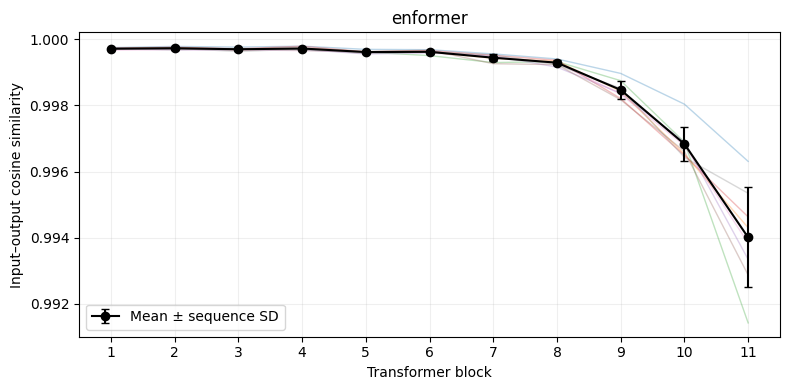

borzoi — cosine similarity for each layer and sequence


sequence_id,chr22_21767168,chr22_23864320,chr22_27010048,chr22_33301504,chr22_35398656,chr22_44835840,chr22_45884416,chr22_50078720
block,,,,,,,,
1,0.986890,0.985403,0.985099,0.988184,0.985618,0.984091,0.982532,0.981881
2,0.994124,0.993569,0.991856,0.993752,0.993156,0.993092,0.992264,0.993289
3,0.996487,0.996090,0.994791,0.994662,0.995488,0.995771,0.995311,0.996140
4,0.988125,0.985075,0.987949,0.986935,0.985131,0.987460,0.984890,0.986127
5,0.988563,0.988086,0.990456,0.990664,0.989489,0.989522,0.988472,0.988113
6,0.987279,0.987111,0.991527,0.988558,0.988111,0.987426,0.988142,0.988196
7,0.978345,0.971153,0.981973,0.975664,0.968067,0.972163,0.961158,0.971764
8,0.852257,0.808212,0.865791,0.877791,0.825944,0.803500,0.811989,0.771257


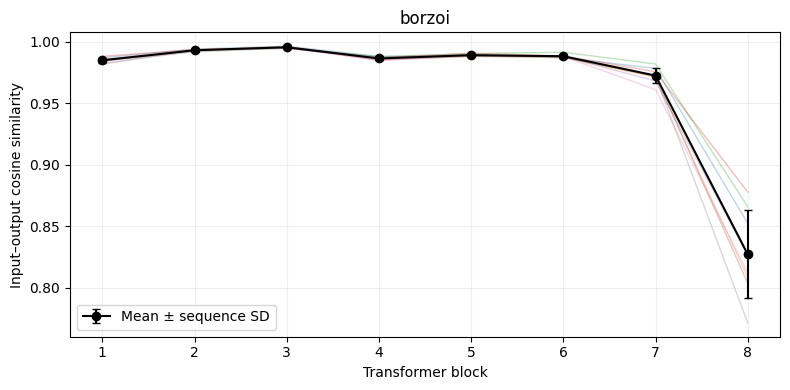

alphagenome — cosine similarity for each layer and sequence


sequence_id,chr22_21767168,chr22_23864320,chr22_27010048,chr22_33301504,chr22_35398656,chr22_44835840,chr22_45884416,chr22_50078720
block,,,,,,,,
1,0.993142,0.991525,0.992226,0.994001,0.990910,0.992724,0.991408,0.991721
2,0.995018,0.995574,0.994683,0.995505,0.994409,0.995826,0.995942,0.994855
3,0.992937,0.993802,0.993653,0.994224,0.993079,0.994495,0.993792,0.994325
4,0.996333,0.995567,0.996654,0.995994,0.994767,0.996161,0.996155,0.994915
5,0.993795,0.993268,0.995782,0.993918,0.993076,0.993755,0.994441,0.993996
6,0.989575,0.988653,0.991866,0.989403,0.988203,0.990202,0.989142,0.989341
7,0.983927,0.984412,0.993605,0.989292,0.983235,0.984655,0.986905,0.985304
8,0.990630,0.989648,0.991036,0.989767,0.988941,0.988828,0.988260,0.990013
9,0.976254,0.970681,0.978329,0.975140,0.965620,0.956491,0.972309,0.955490


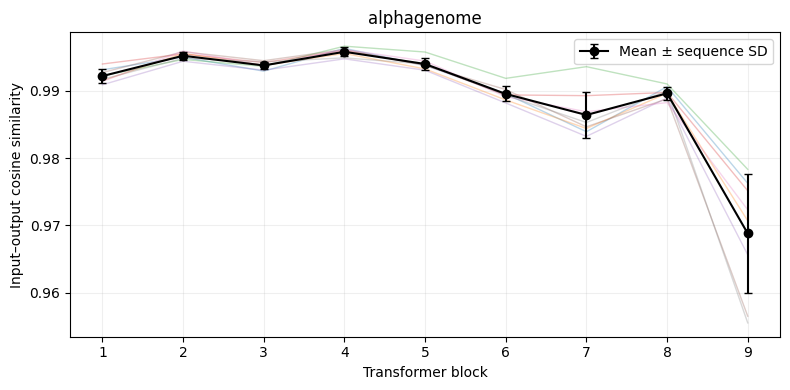

,model,mean_cosine,sd_across_sequences,n_sequences,n_blocks,input_bp
0,enformer,0.998737,0.000197,8,11,196608
1,borzoi,0.967156,0.005441,8,8,524288
2,alphagenome,0.989493,0.001490,8,9,1048576


High cosine does not establish that a layer is unnecessary. These are eight diagnostic hg38 chr22 windows, not a shared held-out benchmark.


In [ ]:
completed=[name for name in LENGTHS if (OUT/f'{name}.complete').exists()]
print('Completed:',completed)
print('Remaining:',[name for name in LENGTHS if name not in completed])
assert completed,'No model has completed yet.'
raw=pd.concat([pd.read_csv(OUT/f'{name}_per_sequence.csv') for name in completed],ignore_index=True)
expected={'enformer':11,'borzoi':8,'alphagenome':9}
for name,g in raw.groupby('model'):
    assert len(g)==N_SEQUENCES*expected[name]
    assert set(g.sequence_id)==set(manifest.sequence_id)
    assert g.groupby('sequence_id').block.nunique().eq(expected[name]).all()
raw.to_csv(OUT/'all_per_sequence.csv',index=False)
per_block=raw.groupby(['model','block'],sort=False).agg(cosine_mean=('cosine','mean'),cosine_sd=('cosine','std'),n_sequences=('sequence_id','nunique'),minimum_valid_tokens=('valid_tokens','min')).reset_index()
per_block.to_csv(OUT/'per_block_summary.csv',index=False)
display(per_block)
for name in completed:
    print(name,'— cosine similarity for each layer and sequence')
    individual=raw[raw.model.eq(name)].pivot(index='block',columns='sequence_id',values='cosine')
    display(individual)
    individual.to_csv(OUT/f'{name}_individual_layers.csv')
    g=per_block[per_block.model.eq(name)]
    fig,ax=plt.subplots(figsize=(8,4))
    for col in individual:ax.plot(individual.index,individual[col],alpha=.3,lw=1)
    ax.errorbar(g.block,g.cosine_mean,yerr=g.cosine_sd,color='black',marker='o',capsize=3,label='Mean ± sequence SD')
    ax.set(xlabel='Transformer block',ylabel='Input–output cosine similarity',title=name)
    ax.set_xticks(g.block);ax.grid(alpha=.2);ax.legend();fig.tight_layout()
    for ext in ['png','pdf']:fig.savefig(OUT/f'{name}_individual_layers.{ext}',dpi=200,bbox_inches='tight')
    plt.show()
sequence_means=raw.groupby(['model','sequence_id'],sort=False).cosine.mean().reset_index()
summary=sequence_means.groupby('model',sort=False).agg(mean_cosine=('cosine','mean'),sd_across_sequences=('cosine','std'),n_sequences=('sequence_id','nunique')).reset_index()
summary['n_blocks']=summary.model.map(expected);summary['input_bp']=summary.model.map(LENGTHS)
summary.to_csv(OUT/'model_summary.csv',index=False);display(summary)
print('High cosine does not establish that a layer is unnecessary. These are eight diagnostic hg38 chr22 windows, not a shared held-out benchmark.')



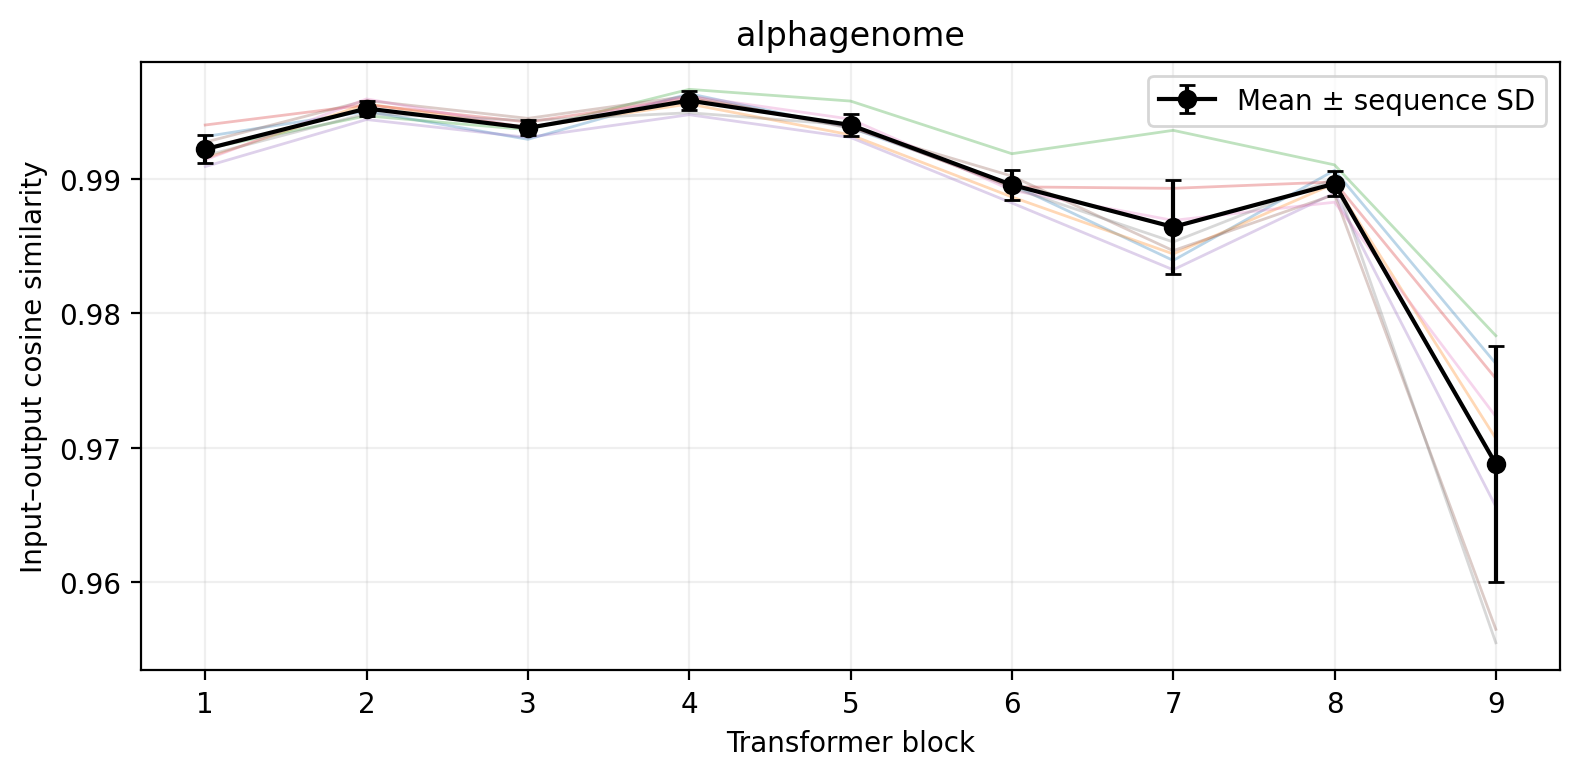
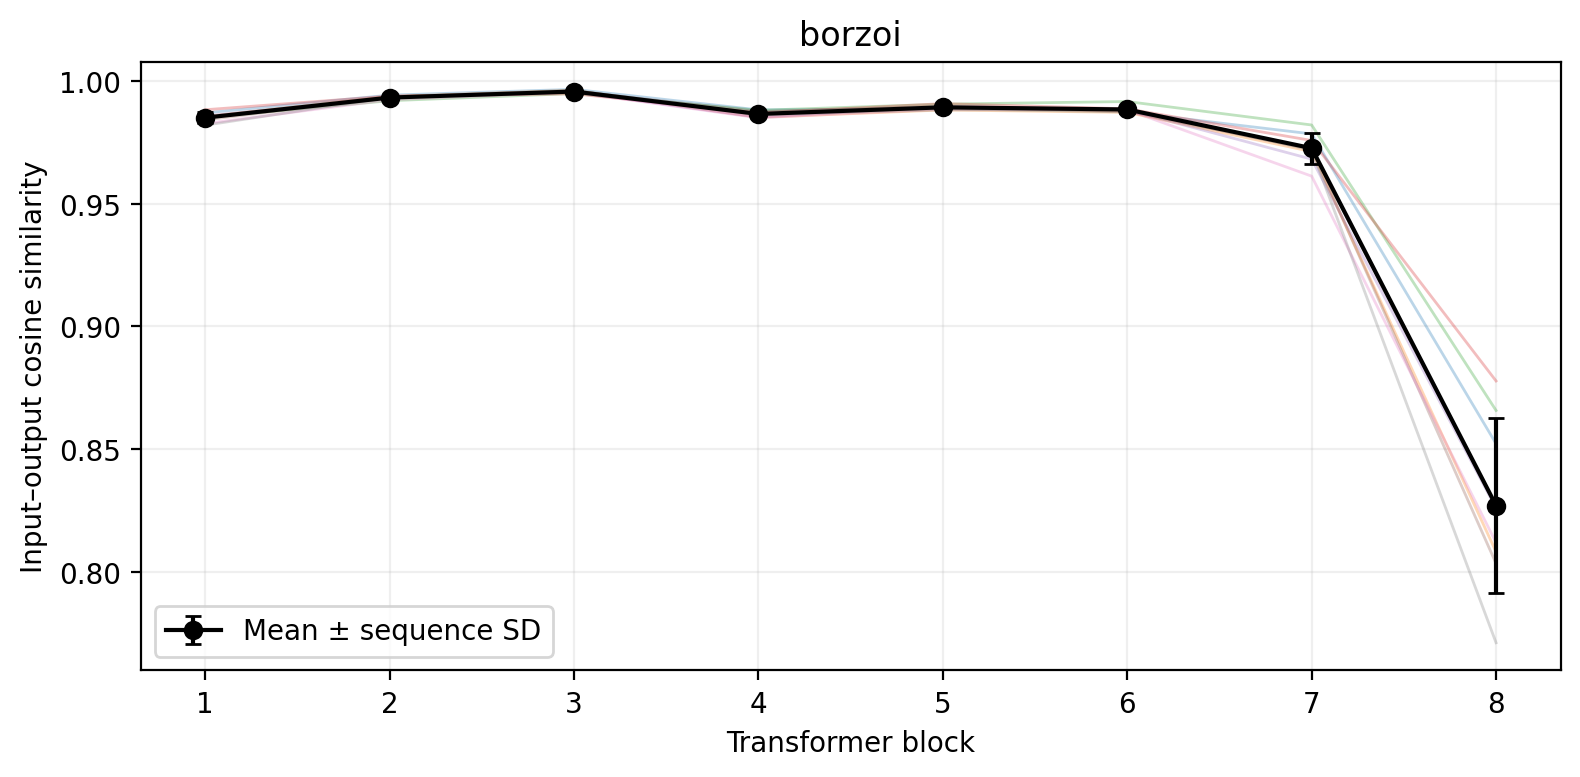
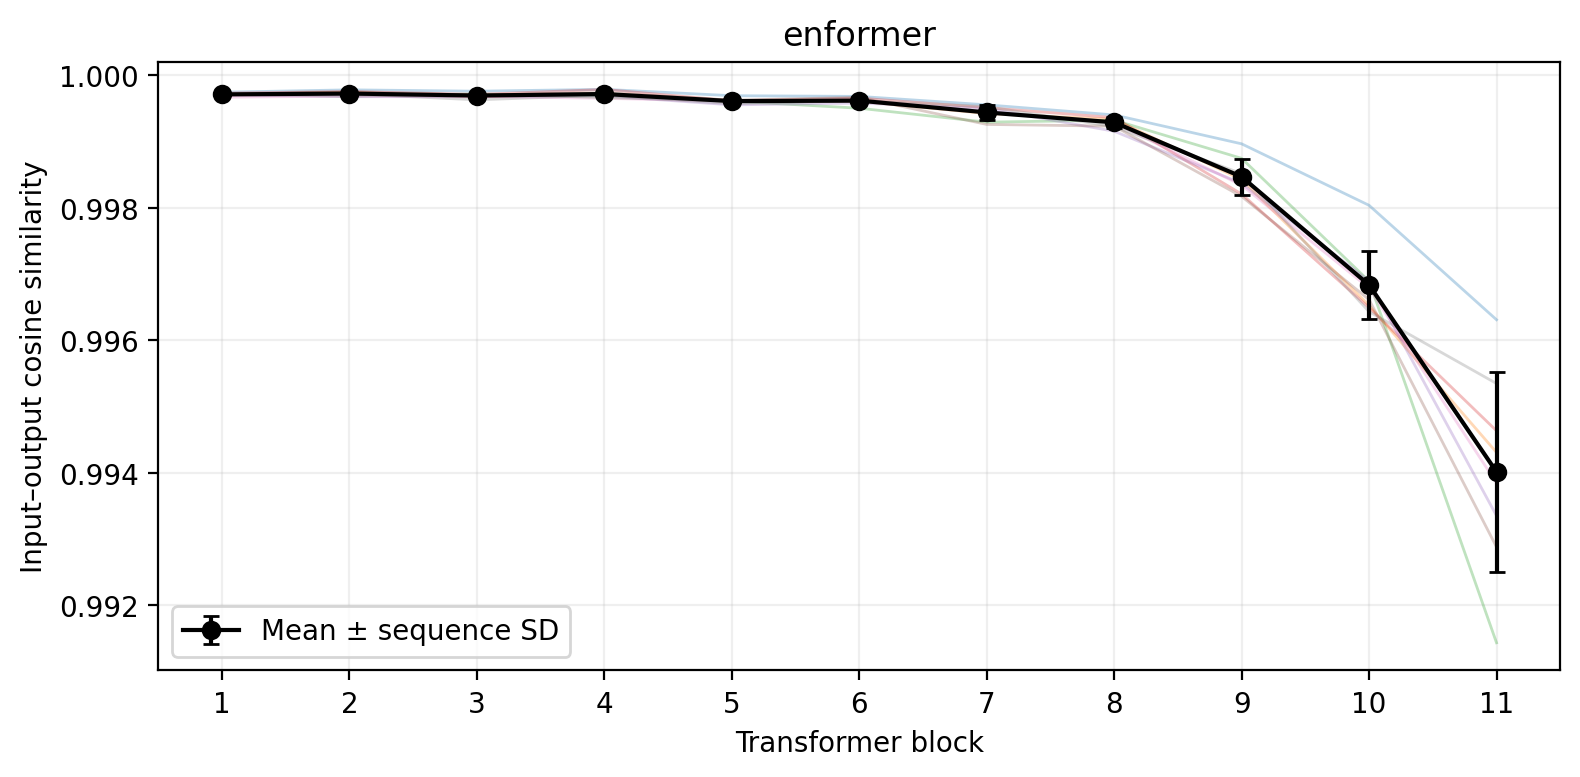

Full-precision results (also retained in saved notebook output):
[{"model":"enformer","sequence_id":"chr22_27010048","block":1,"cosine":0.999713778495789,"valid_tokens":896,"total_tokens":896,"input_bp":196608},{"model":"enformer","sequence_id":"chr22_27010048","block":2,"cosine":0.999682366847992,"valid_tokens":896,"total_tokens":896,"input_bp":196608},{"model":"enformer","sequence_id":"chr22_27010048","block":3,"cosine":0.999717831611633,"valid_tokens":896,"total_tokens":896,"input_bp":196608},{"model":"enformer","sequence_id":"chr22_27010048","block":4,"cosine":0.999663233757019,"valid_tokens":896,"total_tokens":896,"input_bp":196608},{"model":"enformer","sequence_id":"chr22_27010048","block":5,"cosine":0.999609768390656,"valid_tokens":896,"total_tokens":896,"input_bp":196608},{"model":"enformer","sequence_id":"chr22_27010048","block":6,"cosine":0.999502003192902,"valid_tokens":896,"total_tokens":896,"input_bp":196608},{"model":"enformer","sequence_id":"chr22_27010048","block":7,"co

In [ ]:
from IPython.display import HTML,display
import base64,html
links=[]
for path in sorted(OUT.iterdir()):
    if path.suffix not in ['.csv','.png','.pdf','.json','.txt']:continue
    mime={'.png':'image/png','.pdf':'application/pdf','.csv':'text/csv'}.get(path.suffix,'text/plain')
    data=base64.b64encode(path.read_bytes()).decode()
    links.append(f'<li><a download="{html.escape(path.name)}" href="data:{mime};base64,{data}">{html.escape(path.name)}</a></li>')
display(HTML('<h3>Download individual result files</h3><ul>'+''.join(links)+'</ul>'))
print('Full-precision results (also retained in saved notebook output):')
print(raw.to_json(orient='records',double_precision=15))


### What the numbers measure
For each model, each row is one complete transformer block (attention and feed-forward residual updates). Cosine similarity is computed over channels at each position, then averaged over the central 896 positions (114,688 bp). The tables show every layer separately for each of eight shared hg38 chr22 genomic centers. Layer means and standard deviations are across those eight sequences. The additional model average weights each layer equally.

These are diagnostic genomic windows, not a common held-out test split. Enformer uses 196,608 bp, Borzoi 524,288 bp, and AlphaGenome 1,048,576 bp around the same centers. Surrounding context and architecture differ, so cosine is not a model-quality ranking. High cosine does not show that a block is unnecessary; a small residual update can still be important for predictions, and cosine ignores positive rescaling.

AlphaGenome measures the sequence stream while retaining the pair-stream computation. On this T4, unsupported BF16 dot operations use BF16-rounded operands with FP32 accumulation. Its local convolutional encoder runs in overlapping chunks to fit memory; the full context is reassembled before the transformer. A chunked-versus-unchunked check must pass before the analysis runs. This is the official architecture and checkpoint with a documented numerical/backend adaptation, not a bit-identical H100 execution.

Official implementations: [Enformer](https://github.com/google-deepmind/deepmind-research/tree/master/enformer), [Borzoi](https://github.com/calico/borzoi), [Baskerville](https://github.com/calico/baskerville), [AlphaGenome](https://github.com/google-deepmind/alphagenome_research). Source commits, environments, coordinates, and validation results are included in the downloads. The deleted custom RoPE models are omitted.
